# Notebook 06: Limited Predictive Analysis

## GlucoVision Analytics

This notebook performs limited predictive analysis using the cleaned glucose monitoring dataset.

The goal is not to build a medical-grade prediction system, but to create a simple, explainable predictive model that supports dashboard insights.

We will:

- Load the cleaned dataset
- Prepare modeling features
- Create a prediction target
- Split the data into training and testing sets
- Build a baseline model
- Build a Random Forest model
- Evaluate model performance
- Visualize actual vs predicted glucose values
- Analyze feature importance
- Save dashboard-oriented output files

### 2. Import Libraries

Why this step is important

These libraries are required for loading data, preparing features, building models, evaluating predictions, and creating visualizations.

Consequence if skipped

The notebook will fail because required functions for modeling and evaluation will not be available.

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Chart styling
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="tab10"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

### 3. Set Paths

Why this step is important

Using paths makes the notebook organized and reusable.

Consequence if skipped

Files may be loaded or saved in the wrong location, making the project harder to maintain.

In [2]:
DATA_DIR = "../data/processed"
OUTPUT_DIR = "../outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

cleaned_data_path = os.path.join(DATA_DIR, "glucovision_cleaned_preprocessed.csv")

### 4. Load Dataset

Why this step is important

Before modeling, we need to confirm that the cleaned dataset loads correctly.

Consequence if skipped

We may build a model on the wrong file or incomplete data without realizing it.

In [3]:
df = pd.read_csv(cleaned_data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (309392, 23)


,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff,is_low_glucose,is_high_glucose,glucose_category,hour,day,day_of_week,date,month,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
0,2018-06-13 18:40:00,332.0,6.3595,82.322835,34.0,0.091667,0.0,0.0,HUPA0001P,NaN,False,True,High,18,13,Wednesday,2018-06-13,6,NaN,NaN,NaN,332.000000,332.000000
1,2018-06-13 18:45:00,326.0,7.7280,83.740157,0.0,0.091667,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,18,13,Wednesday,2018-06-13,6,332.0,NaN,NaN,329.000000,329.000000
2,2018-06-13 18:50:00,330.0,4.7495,80.525180,0.0,0.091667,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,18,13,Wednesday,2018-06-13,6,326.0,NaN,NaN,329.333333,329.333333
3,2018-06-13 18:55:00,324.0,6.3595,89.129032,20.0,0.091667,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,18,13,Wednesday,2018-06-13,6,330.0,332.0,NaN,328.000000,328.000000
4,2018-06-13 19:00:00,306.0,5.1520,92.495652,0.0,0.075000,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,19,13,Wednesday,2018-06-13,6,324.0,326.0,NaN,323.600000,323.600000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309392 entries, 0 to 309391
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   time                    309392 non-null  str    
 1   glucose                 309392 non-null  float64
 2   calories                309392 non-null  float64
 3   heart_rate              309392 non-null  float64
 4   steps                   309392 non-null  float64
 5   basal_rate              309392 non-null  float64
 6   bolus_volume_delivered  309392 non-null  float64
 7   carb_input              309392 non-null  float64
 8   patient_id              309392 non-null  str    
 9   time_diff               309367 non-null  str    
 10  is_low_glucose          309392 non-null  bool   
 11  is_high_glucose         309392 non-null  bool   
 12  glucose_category        309392 non-null  str    
 13  hour                    309392 non-null  int64  
 14  day                     309392 

### 5. Convert Time Column

Why this step is important

The time column must be in datetime format for time-based sorting and validation.

Consequence if skipped

Time-series calculations and chronological splitting may not work correctly.

In [5]:
df["time"] = pd.to_datetime(df["time"])

print(df["time"].min())
print(df["time"].max())

2018-06-13 18:40:00
2022-05-18 12:15:00


### 6. Sort Data

Why this step is important

Glucose data is time-series data. Sorting ensures that lag and rolling features are aligned correctly.

Consequence if skipped

The model may learn from incorrectly ordered records, which can reduce prediction quality.

In [6]:
df = df.sort_values(["patient_id", "time"]).reset_index(drop=True)

df.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff,is_low_glucose,is_high_glucose,glucose_category,hour,day,day_of_week,date,month,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
0,2018-06-13 18:40:00,332.0,6.3595,82.322835,34.0,0.091667,0.0,0.0,HUPA0001P,NaN,False,True,High,18,13,Wednesday,2018-06-13,6,NaN,NaN,NaN,332.000000,332.000000
1,2018-06-13 18:45:00,326.0,7.7280,83.740157,0.0,0.091667,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,18,13,Wednesday,2018-06-13,6,332.0,NaN,NaN,329.000000,329.000000
2,2018-06-13 18:50:00,330.0,4.7495,80.525180,0.0,0.091667,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,18,13,Wednesday,2018-06-13,6,326.0,NaN,NaN,329.333333,329.333333
3,2018-06-13 18:55:00,324.0,6.3595,89.129032,20.0,0.091667,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,18,13,Wednesday,2018-06-13,6,330.0,332.0,NaN,328.000000,328.000000
4,2018-06-13 19:00:00,306.0,5.1520,92.495652,0.0,0.075000,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,19,13,Wednesday,2018-06-13,6,324.0,326.0,NaN,323.600000,323.600000


### 7. Create Prediction Target

Why this step is important

Predictive modeling needs a target variable. Here, the model learns to predict the next glucose reading.

Consequence if skipped

There will be no prediction goal for the model.

In [7]:
df["target_glucose_next"] = df.groupby("patient_id")["glucose"].shift(-1)

df[["patient_id", "time", "glucose", "target_glucose_next"]].head()

,patient_id,time,glucose,target_glucose_next
0,HUPA0001P,2018-06-13 18:40:00,332.0,326.0
1,HUPA0001P,2018-06-13 18:45:00,326.0,330.0
2,HUPA0001P,2018-06-13 18:50:00,330.0,324.0
3,HUPA0001P,2018-06-13 18:55:00,324.0,306.0
4,HUPA0001P,2018-06-13 19:00:00,306.0,313.0


### 8. Remove Rows Without Target

Why this step is important

The last record for each patient will not have a next glucose value, so it cannot be used for supervised learning.

Consequence if skipped

The model training step may fail because the target contains missing values.

In [8]:
df_model = df.dropna(subset=["target_glucose_next"]).copy()

print("Modeling dataset shape:", df_model.shape)

Modeling dataset shape: (309367, 24)


### 9. Select Features

Why this step is important

Feature selection decides what information the model can use to make predictions.

Consequence if skipped

The model may include irrelevant columns or fail because some columns are not suitable for modeling.

In [9]:
feature_cols = [
    "glucose",
    "calories",
    "heart_rate",
    "steps",
    "basal_rate",
    "bolus_volume_delivered",
    "carb_input",
    "hour",
    "day",
    "day_of_week",
    "glucose_lag_1",
    "glucose_lag_2",
    "glucose_lag_3",
    "glucose_rolling_mean_3",
    "glucose_rolling_mean_6"
]

available_features = [col for col in feature_cols if col in df_model.columns]

print("Available features:")
available_features

Available features:


['glucose',
 'calories',
 'heart_rate',
 'steps',
 'basal_rate',
 'bolus_volume_delivered',
 'carb_input',
 'hour',
 'day',
 'day_of_week',
 'glucose_lag_1',
 'glucose_lag_3']

### 10. Prepare X and y

Why this step is important

Machine learning models require input features `X` and target values `y`.

Consequence if skipped

The model cannot be trained.

In [10]:
X = df_model[available_features].copy()
y = df_model["target_glucose_next"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (309367, 12)
y shape: (309367,)


### 11. Handle Missing Feature Values

Why this step is important

Most machine learning models cannot handle missing values directly.

Consequence if skipped

Model training may fail with missing-value errors.

In [11]:
missing_values = X.isna().sum()
missing_values[missing_values > 0]

glucose_lag_1    25
glucose_lag_3    75
dtype: int64

In [12]:
# Convert all object/text columns into numeric dummy columns
X = pd.get_dummies(X, drop_first=True)

# Fill any missing values
X = X.fillna(X.median(numeric_only=True))

# Confirm no text columns remain
print(X.dtypes)
print("Text columns remaining:", X.select_dtypes(include="object").columns.tolist())

glucose                   float64
calories                  float64
heart_rate                float64
steps                     float64
basal_rate                float64
bolus_volume_delivered    float64
carb_input                float64
hour                        int64
day                         int64
glucose_lag_1             float64
glucose_lag_3             float64
day_of_week_Monday           bool
day_of_week_Saturday         bool
day_of_week_Sunday           bool
day_of_week_Thursday         bool
day_of_week_Tuesday          bool
day_of_week_Wednesday        bool
dtype: object
Text columns remaining: []


### 12. Train/Test Split

Why this step is important

A train/test split allows us to train the model on one part of the data and evaluate it on unseen data.

Consequence if skipped

We cannot know how well the model performs on new data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print(X_train.shape)
print(X_test.shape)

Training rows: 247493
Testing rows: 61874
(247493, 17)
(61874, 17)


### 13. Define Evaluation Function

Why this step is important

Using one evaluation function keeps model comparison consistent.

Consequence if skipped

Evaluation may become repetitive and inconsistent across models.

In [14]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### 14. Baseline Model

Why this step is important

A baseline model gives us a simple benchmark. Any useful model should perform better than this.

Consequence if skipped

We will not know whether the Random Forest model is actually adding value.

In [15]:
baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_results = evaluate_model(
    "Baseline Mean Model",
    y_test,
    baseline_pred
)

baseline_results

{'model': 'Baseline Mean Model',
 'MAE': 44.70558409802117,
 'RMSE': np.float64(57.08599665823378),
 'R2': -7.4774910965302865e-06}

### 15. Random Forest Model

Why this step is important

Random Forest is useful because it can capture non-linear relationships between glucose patterns and future glucose values.

Consequence if skipped

The project would only include a very basic model and would miss an important predictive analysis component.

In [16]:
# FULL FIX: rebuild modeling data from scratch

# 1. Recreate feature list, but remove text-based day_of_week if needed
feature_cols = [
    "glucose",
    "calories",
    "heart_rate",
    "steps",
    "basal_rate",
    "bolus_volume_delivered",
    "carb_input",
    "hour",
    "day",
    "glucose_lag_1",
    "glucose_lag_2",
    "glucose_lag_3",
    "glucose_rolling_mean_3",
    "glucose_rolling_mean_6"
]

available_features = [col for col in feature_cols if col in df_model.columns]

# 2. Recreate X and y
X = df_model[available_features].copy()
y = df_model["target_glucose_next"].copy()

# 3. Keep numeric columns only
X = X.select_dtypes(include=["int64", "float64", "int32", "float32"])

# 4. Fill missing values
X = X.fillna(X.median(numeric_only=True))

# 5. Recreate train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 6. Final check
print("Text columns in X_train:", X_train.select_dtypes(include="object").columns.tolist())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Text columns in X_train: []
X_train shape: (247493, 11)
X_test shape: (61874, 11)


In [17]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 16. Compare Model Results

Why this step is important

Saving model evaluation results makes them available for the Streamlit dashboard and final project summary.

Consequence if skipped

Dashboard metrics would need to be recalculated manually.

In [18]:
# Random Forest predictions

rf_pred = rf_model.predict(X_test)

print("Predictions created successfully.")

Predictions created successfully.


In [19]:
# Evaluate Random Forest model

rf_results = evaluate_model(
    "Random Forest Regressor",
    y_test,
    rf_pred
)

rf_results

{'model': 'Random Forest Regressor',
 'MAE': 1.788750673769989,
 'RMSE': np.float64(4.056147382443357),
 'R2': 0.9949513934569256}

In [20]:
model_results_df = pd.DataFrame([
    baseline_results,
    rf_results
])

model_results_df

,model,MAE,RMSE,R2
0,Baseline Mean Model,44.705584,57.085997,-0.000007
1,Random Forest Regressor,1.788751,4.056147,0.994951


In [21]:
model_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "predictive_model_evaluation.csv"),
    index=False
)

### 17. Actual vs Predicted DataFrame

Why this step is important

This output helps compare predicted glucose values with actual glucose values.

Consequence if skipped

The dashboard cannot show prediction accuracy visually.

In [22]:
predictions_df = pd.DataFrame({
    "actual_glucose": y_test.values,
    "predicted_glucose": rf_pred
})

predictions_df["prediction_error"] = predictions_df["actual_glucose"] - predictions_df["predicted_glucose"]
predictions_df["absolute_error"] = predictions_df["prediction_error"].abs()

predictions_df.head()

,actual_glucose,predicted_glucose,prediction_error,absolute_error
0,129.333333,129.049152,0.284181,0.284181
1,175.000000,173.064038,1.935962,1.935962
2,91.000000,90.318829,0.681171,0.681171
3,122.000000,122.785015,-0.785015,0.785015
4,140.666667,137.753766,2.912901,2.912901


In [23]:
predictions_df.to_csv(
    os.path.join(OUTPUT_DIR, "actual_vs_predicted_glucose.csv"),
    index=False
)

### 18. Actual vs Predicted Visualization

Why this step is important

This chart shows how close predictions are to actual glucose readings.

Consequence if skipped

The model performance would be harder to understand visually.

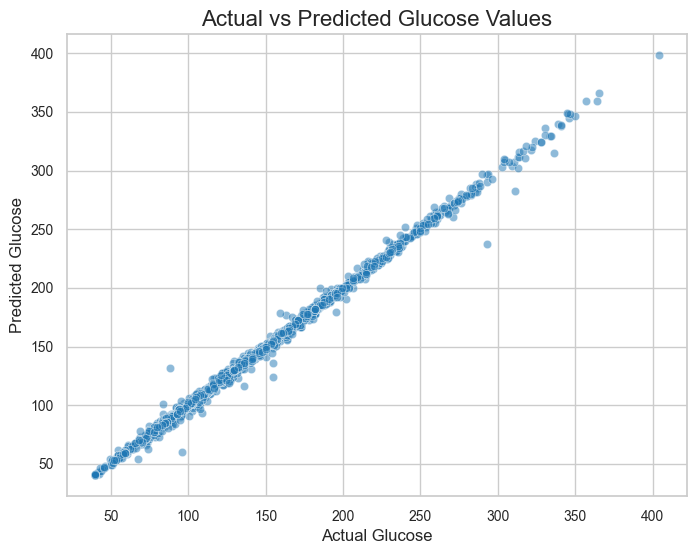

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=predictions_df.sample(min(2000, len(predictions_df)), random_state=42),
    x="actual_glucose",
    y="predicted_glucose",
    alpha=0.5
)

plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Actual vs Predicted Glucose Values")

plt.show()

## 19. Prediction Error Distribution

Why this step is important

The error distribution shows whether the model tends to overpredict or underpredict glucose values.

Consequence if skipped

We may miss important patterns in model errors.

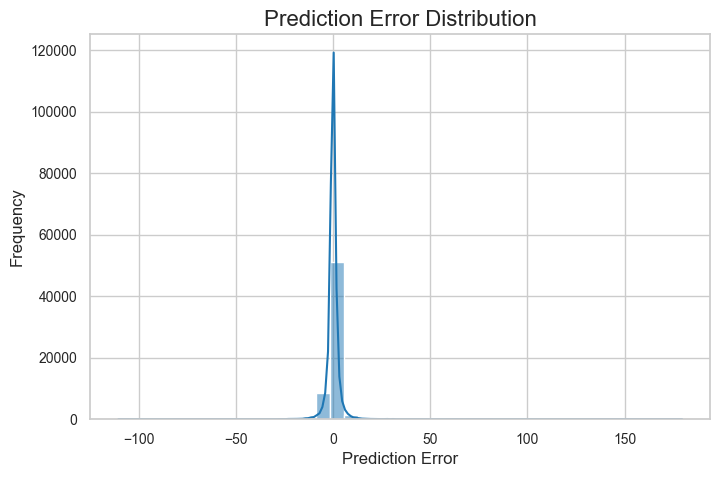

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    predictions_df["prediction_error"],
    bins=40,
    kde=True
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")

plt.show()

### 20. Feature Importance

Why this step is important

Feature importance helps explain which variables influenced the prediction most.

Consequence if skipped

The predictive model would be less interpretable.

In [26]:
feature_importance_df = pd.DataFrame({
    "feature": available_features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance
0,glucose,0.995415
9,glucose_lag_1,0.002347
10,glucose_lag_3,0.001803
5,bolus_volume_delivered,0.000090
1,calories,0.000072
2,heart_rate,0.000066
4,basal_rate,0.000053
6,carb_input,0.000046
8,day,0.000045
7,hour,0.000041


In [27]:
feature_importance_df.to_csv(
    os.path.join(OUTPUT_DIR, "predictive_feature_importance.csv"),
    index=False
)

### 21. Feature Importance Visualization

Why this step is important

This chart makes model interpretation easier for viewers and dashboard users.

Consequence if skipped

Feature importance would be available only as a table, which is less intuitive.

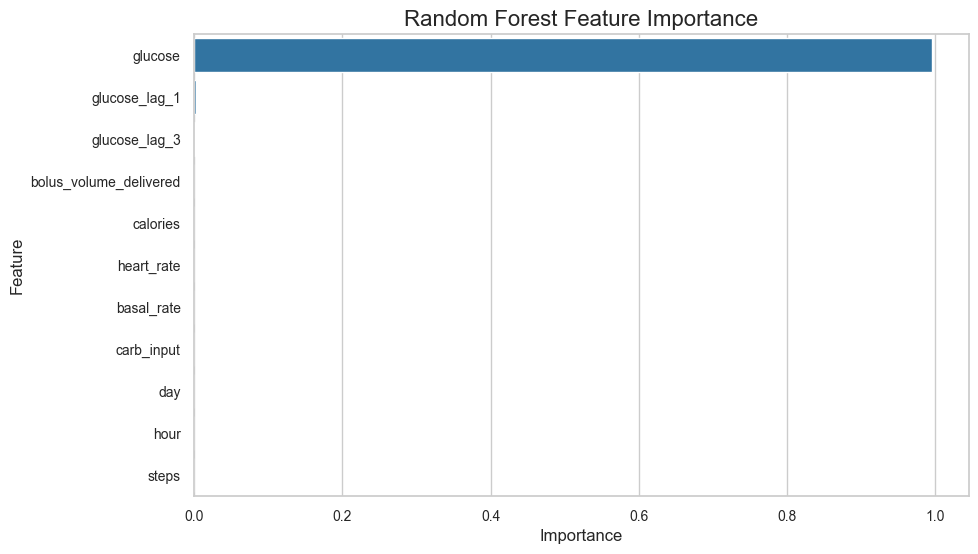

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

### 22. Dashboard Summary Output

Why this step is important

This file provides clean predictive metrics for the Streamlit dashboard.

Consequence if skipped

The dashboard would need to calculate model metrics directly, making it slower and more complex.

In [29]:
dashboard_predictive_summary = pd.DataFrame({
    "metric": [
        "baseline_mae",
        "baseline_rmse",
        "baseline_r2",
        "random_forest_mae",
        "random_forest_rmse",
        "random_forest_r2"
    ],
    "value": [
        baseline_results["MAE"],
        baseline_results["RMSE"],
        baseline_results["R2"],
        rf_results["MAE"],
        rf_results["RMSE"],
        rf_results["R2"]
    ]
})

dashboard_predictive_summary

,metric,value
0,baseline_mae,44.705584
1,baseline_rmse,57.085997
2,baseline_r2,-0.000007
3,random_forest_mae,1.788751
4,random_forest_rmse,4.056147
5,random_forest_r2,0.994951


In [30]:
dashboard_predictive_summary.to_csv(
    os.path.join(OUTPUT_DIR, "predictive_dashboard_summary.csv"),
    index=False
)

### 23. Key Findings

- A baseline model was created using the mean glucose value.
- A Random Forest Regressor was trained to predict the next glucose reading.
- Model performance was evaluated using MAE, RMSE, and R².
- Actual vs predicted visualization was created to assess prediction quality.
- Feature importance was calculated to understand which variables influenced predictions.
- Dashboard-ready predictive output files were saved.

### 24. Limitations

This predictive analysis is intentionally limited.

Important limitations include:

- The model predicts only the next glucose value.
- The train/test split is simple and does not fully account for patient-level separation.
- The model should not be used for medical decision-making.
- The purpose is project demonstration and dashboard support, not clinical deployment.

### 25. Output Files Created

### Predictive Analysis Output Files

This notebook creates the following files:

- predictive_model_evaluation.csv
- actual_vs_predicted_glucose.csv
- predictive_feature_importance.csv
- predictive_dashboard_summary.csv

In [31]:
os.listdir(OUTPUT_DIR)

['activity_glucose_summary.csv',
 'actual_vs_predicted_glucose.csv',
 'daily_glucose_summary.csv',
 'descriptive_kpi_summary.csv',
 'glucose_category_counts.csv',
 'glucose_category_percentages.csv',
 'hourly_glucose_summary.csv',
 'hourly_risk_recommendations.csv',
 'patient_descriptive_summary.csv',
 'patient_risk_segmentation.csv',
 'patient_risk_summary.csv',
 'predictive_dashboard_summary.csv',
 'predictive_feature_importance.csv',
 'predictive_model_evaluation.csv',
 'prescriptive_dashboard_summary.csv',
 'weekday_glucose_summary.csv']